## 📊 Stock Market Prediction using LSTM

### Project Overview
This project implements a Long Short-Term Memory (LSTM) neural network to predict stock prices using historical data. It focuses on modeling the temporal dependencies in stock trends to forecast future prices effectively.

###  Objective
To predict the closing prices of a selected S&P 500 stock (e.g., Apple - AAPL) using a deep learning model trained on time-series data.

### 📚 Dataset
- **Source**: [S&P 500 Stock Data on Kaggle](https://www.kaggle.com/datasets/camnugent/sandp500)
- **Features**:
  - Daily stock prices for companies in the S&P 500
  - Columns include:
    - `date`: Trading date
    - `open`: Opening price
    - `high`: Highest price of the day
    - `low`: Lowest price of the day
    - `close`: Closing price
    - `volume`: Number of shares traded
    - `Name`: Company ticker symbol

### 🛠️ Technologies Used
- Python 3
- TensorFlow / Keras
- Pandas & NumPy
- Scikit-learn
- Matplotlib

### Workflow
1. **Data Preprocessing**
   - Filter by stock ticker (e.g., AAPL)
   - Convert date column to datetime
   - Normalize prices using `MinMaxScaler`

2. **Sequence Generation**
   - Create 60-day time windows of past data
   - Reshape for LSTM input

3. **Model Design**
   - LSTM layers with dropout for regularization
   - Compiled using Adam optimizer and MSE loss

4. **Training & Evaluation**
   - Trained on historical closing prices
   - Predicted results compared visually with actual prices

### 📈 Results
The model learns temporal stock price patterns and produces reasonable trend predictions on historical data. Results are visualized with line plots comparing actual vs predicted prices.



In [13]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [23]:
# Load dataset
df = pd.read_csv("all_stocks_5yr.csv")  # Update filename if different
print(df.columns)

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name'], dtype='object')


In [24]:
# Filter one stock, e.g., Apple
aapl_df = df[df['Name'] == 'AAPL'].copy()

In [25]:
# Convert date to datetime and sort
aapl_df['date'] = pd.to_datetime(aapl_df['date'])
aapl_df = aapl_df.sort_values('date')

In [26]:
# Use only the closing price
data = aapl_df['close'].values.reshape(-1, 1)

In [27]:
# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [29]:
# Create training sequences
sequence_length = 60
x_train, y_train = [], []

for i in range(sequence_length, len(scaled_data)):
    x_train.append(scaled_data[i-sequence_length:i])
    y_train.append(scaled_data[i])

x_train, y_train = np.array(x_train), np.array(y_train)

In [30]:
# Reshape input for LSTM: [samples, time steps, features]
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)

In [31]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))  # Output layer


C:\Users\njavanba\.conda\envs\cleanml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
# Compile and train
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=10, batch_size=32)


Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - loss: 0.1058
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0048 
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0040 
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0036 
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0029 
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0026 
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0039 
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0030 
Epoch 9/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0029 
Epoch 10/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0025 


In [33]:
# Predict and plot
predicted_prices = model.predict(x_train)
predicted_prices = scaler.inverse_transform(predicted_prices)
actual_prices = scaler.inverse_transform(y_train.reshape(-1, 1))

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step  


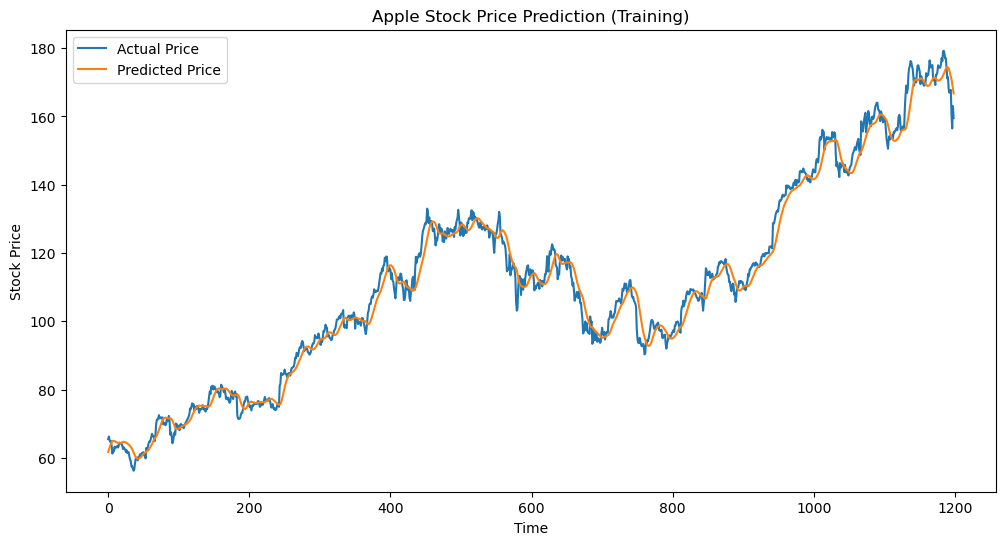

In [34]:
# Visualization
plt.figure(figsize=(12,6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.title("Apple Stock Price Prediction (Training)")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()